# Third-Party Liability Claim Frequency Dataset
### Scott Schmidt
*M.S. Computer Science Student, Illinois State University*

This project analyzes the French Motor Third-Party Liability Claim Frequency dataset (`freMTPL2freq`). The dataset contains automobile insurance policies from an unidentified private French insurer, with most policies observed for approximately one year between 2011 and 2013. It is used to examine whether policy and driver characteristics can help predict whether a policyholder will file one or more claims.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

dataset = fetch_openml(
    data_id=41214,
    as_frame=True
)

df = dataset.frame
df.columns = df.columns.str.strip()

print(df.shape)
print(df.head())
print(df.columns)
df.head()

(678013, 12)
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand     VehGas  Density Region  
0      B12  'Regular'     1217    R82  
1      B12  'Regular'     1217    R82  
2      B12   'Diesel'       54    R22  
3      B12   'Diesel'       76    R72  
4      B12   'Diesel'       76    R72  
Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='object')


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


## Analyze Missing Values

In [2]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

missing_summary

,Missing Count,Missing Percent


## Analyze Target Variable 
The original claim-count is highly imbalanced especially for polciies with many claims.
* Only 373 test policies had 2+ claims.
* The model correctly predicted none of them.
* It correctly identified only 24 of 6,473 one-claim policies.
* The 94.94% accuracy mostly came from the zero-claim group.
Because the model cannot reliably distinguish between the rare claim-count categories, the target is converted into a binary variable:
0 for no claim and 1 for one or more claims. This is better aligned with the research objective and also becomes easier to intpret later. 

In [3]:
claim_counts = (
    df["ClaimNb"]
    .value_counts()
    .sort_index()
    .rename_axis("Claim Count")
    .reset_index(name="Number of Policies")
)

claim_counts["Percentage"] = (
    claim_counts["Number of Policies"] / len(df) * 100
).round(2)

display(claim_counts.style.hide(axis="index"))

Claim Count,Number of Policies,Percentage
0,643953,94.980000
1,32178,4.750000
2,1784,0.260000
3,82,0.010000
4,7,0.000000
5,2,0.000000
6,1,0.000000
8,1,0.000000
9,1,0.000000
11,3,0.000000


In [4]:
df["ClaimNb"] = df["ClaimNb"].clip(upper=1)

## Feature Engineering
Categorical variables were converted into dummy variables using one-hot encoding. This created a separate binary column for each category, allowing the models to use categorical information without incorrectly treating the categories as numerical values.

In [5]:
categorical_columns = [
    "Area",
    "VehBrand",
    "VehGas",
    "Region"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

df.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,Area_B,Area_C,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,1.0,1,0.10,5,0,55,50,1217,0,0,...,0,0,0,0,0,1,0,0,0,0
1,3.0,1,0.77,5,0,55,50,1217,0,0,...,0,0,0,0,0,1,0,0,0,0
2,5.0,1,0.75,6,2,52,50,54,1,0,...,0,0,0,0,0,0,0,0,0,0
3,10.0,1,0.09,7,0,46,50,76,1,0,...,0,0,1,0,0,0,0,0,0,0
4,11.0,1,0.84,7,0,46,50,76,1,0,...,0,0,1,0,0,0,0,0,0,0


# 

In [6]:
# 1. Separate features (X) and target variable (y)
X = df.select_dtypes(include=[np.number]).drop(columns=["ClaimNb", "IDpol"], errors="ignore")
y = df["ClaimNb"]

# 2. Perform the split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,       # 20% reserved for testing
    random_state=42,    # Sets random seed for reproducible results
    stratify = y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")

Training features shape: (542410, 43)
Testing features shape:  (135603, 43)


In [7]:
numeric_columns = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [8]:
xgb_classifier = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=11,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

xgb_classifier.fit(X_train, y_train)

feature_importance_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": xgb_classifier.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(20)

,Feature,Importance
0,Exposure,0.205381
1,VehAge,0.154147
2,BonusMalus,0.137896
3,VehGas_'Regular',0.101949
4,VehBrand_B12,0.092394
5,DrivAge,0.054081
6,VehPower,0.028962
7,Region_R24,0.027314
8,Region_R53,0.021031
9,Region_R82,0.020039


In [9]:
zero_importance_features = feature_importance_df.loc[
    feature_importance_df["Importance"] == 0,
    "Feature"
].tolist()

X_train_reduced = X_train.drop(
    columns=zero_importance_features
)

X_test_reduced = X_test.drop(
    columns=zero_importance_features
)

print("Original features:", X_train.shape[1])
print("Reduced features:", X_train_reduced.shape[1])

Original features: 43
Reduced features: 26


# Feature Importance and Effect of Categorical Variables
Adding categorical variables and removing features with zero importance improved the model. 
Below is the updated model metrics:
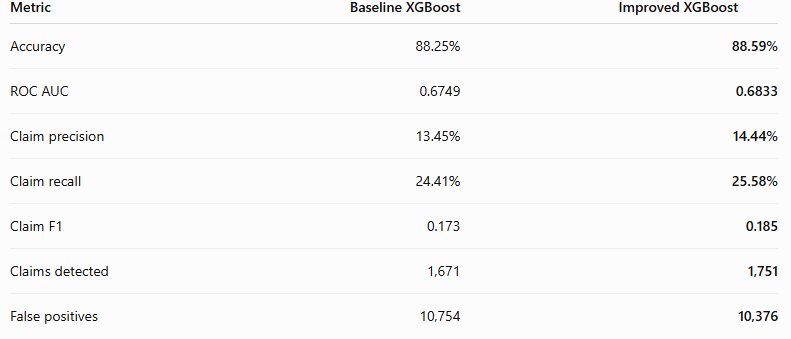

# Weight Analysis 
Increasing the claim-class weight caused the model to identify more policies with claims, but it also reduced accuracy and increased false positives. A weight of 11 provided the best overall balance, achieving 88.59% accuracy, 25.58% claim recall, and the highest claim F1 score of 0.185. ROC AUC remained relatively stable across the different weights.
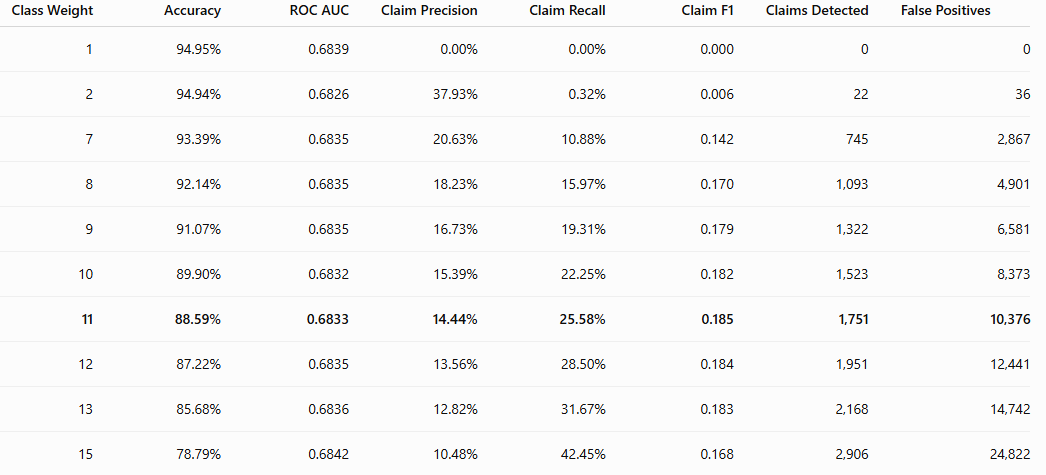

In [10]:
def run_xgb_weights():
    for weight in [1, 2, 7, 8, 9, 10, 11, 12, 13, 15]:
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            scale_pos_weight=weight,
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
        model.fit(X_train, y_train)
    
        y_pred_weight = model.predict(X_test)
        y_prob_weight = model.predict_proba(X_test)[:, 1]
    
        weight_accuracy = accuracy_score(y_test, y_pred_weight)
        weight_roc_auc = roc_auc_score(y_test, y_prob_weight)
    
        print(f"\nWeight: {weight}")
        print(f"Accuracy: {weight_accuracy * 100:.2f}%")
        print(f"ROC AUC: {weight_roc_auc:.4f}")
    
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred_weight))
    
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred_weight))
# run_xgb_weights()

# Final XGBoost Model and Metrics

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

xgb_classifier = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=11,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
xgb_classifier.fit(X_train, y_train)

# Predicted classes
y_pred_xgb = xgb_classifier.predict(X_test)

# Predicted probability of a claim
y_prob_xgb = xgb_classifier.predict_proba(X_test)[:, 1]

# Calculate metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_confusion_matrix = confusion_matrix(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

# Print results
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

print("\nXGBoost Confusion Matrix:")
print(xgb_confusion_matrix)

print(f"\nXGBoost ROC AUC: {xgb_roc_auc:.4f}")

XGBoost Accuracy: 87.89%

XGBoost Confusion Matrix:
[[117238  11553]
 [  4870   1942]]

XGBoost ROC AUC: 0.6963


## SHAP Interpretation 
SHAP values are used to explain how variables influence the final XGBoost prediction. 
Unlike logistic regression coefficients, SHAP values are not fixed effects that apply to every observation. Instead, each SHAP value represents how much a feature contributed to a specific policy prediction. 

SHAP sample shape: (3000, 43)


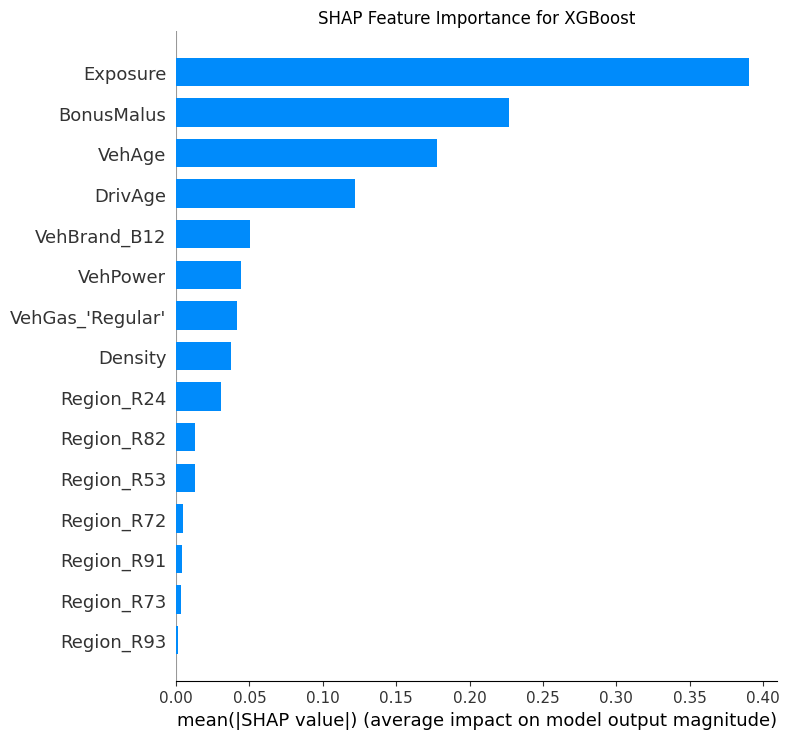

In [12]:
import shap
import matplotlib.pyplot as plt

# Use a sample so SHAP runs faster
X_shap = X_test.sample(
    n=min(3000, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("SHAP Feature Importance for XGBoost")
plt.tight_layout()
plt.show()

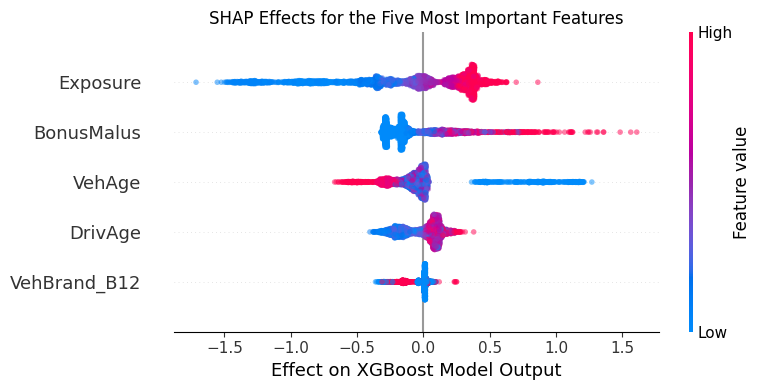

In [13]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=5,
    plot_size=(8, 4),
    alpha=0.5,
    show=False
)

plt.title("SHAP Effects for the Five Most Important Features")
plt.xlabel("Effect on XGBoost Model Output")
plt.tight_layout()
plt.show()

## Logistic Regression Class Weights
Increasing the weight assigned to the claim class makes errors on claim policies more costly, helping the model detect claims more frequently. However, higher claim recall often reduces overall accuracy by producing more false positives. A class weight of 12 provided a reasonable balance, improving claim recall while maintaining an overall accuracy of approximately 85%. 

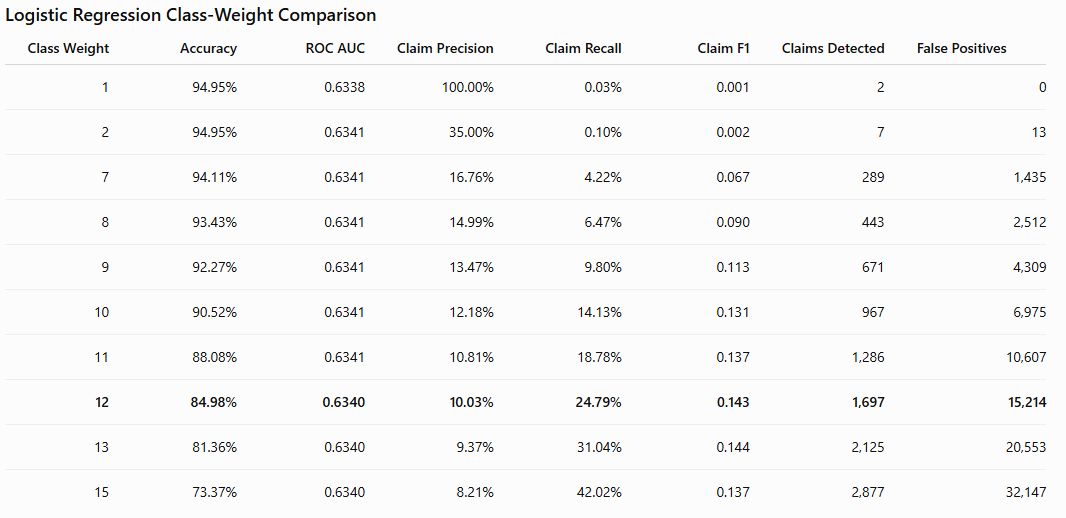

In [14]:
def evaluate_logistic_weights():
    weights = [1, 2, 7, 8, 9, 10, 11, 12, 13, 15]

    for weight in weights:
        logistic_model = LogisticRegression(
            class_weight={0: 1, 1: weight},
            max_iter=500,
            random_state=42
        )

        # Use scaled training data
        logistic_model.fit(X_train_scaled, y_train)

        # Use scaled testing data
        y_pred_logistic = logistic_model.predict(
            X_test_scaled
        )

        y_prob_logistic = logistic_model.predict_proba(
            X_test_scaled
        )[:, 1]

        logistic_accuracy = accuracy_score(
            y_test,
            y_pred_logistic
        )

        logistic_roc_auc = roc_auc_score(
            y_test,
            y_prob_logistic
        )

        print(f"\nWeight: {weight}")
        print(f"Accuracy: {logistic_accuracy * 100:.2f}%")
        print(f"ROC AUC: {logistic_roc_auc:.4f}")

        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred_logistic))

        print("\nClassification Report:")
        print(
            classification_report(
                y_test,
                y_pred_logistic,
                zero_division=0
            )
        )
# evaluate_logistic_weights()

# Final Logistic Regression model

In [15]:
logistic_model = LogisticRegression(
    class_weight={0: 1, 1: 12},
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print(f"Accuracy: {logistic_accuracy * 100:.2f}%")
print(f"ROC AUC: {logistic_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

Accuracy: 84.98%
ROC AUC: 0.6389

Confusion Matrix:
[[113516  15275]
 [  5089   1723]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92    128791
           1       0.10      0.25      0.14      6812

    accuracy                           0.85    135603
   macro avg       0.53      0.57      0.53    135603
weighted avg       0.91      0.85      0.88    135603



# Compare Models
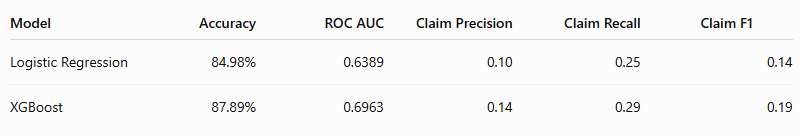

XGBoost performed better across all measures. It has higher overall accuracy while being able to identify a large percentage of claims. 